In [1]:
from datasets import load_dataset

ds = load_dataset("ahmedheakl/arocrbench_bcelayout")

C:\Users\abdo6\OneDrive\Desktop\My_library\0.informatique\python-projects\Test\.venvv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = ds["train"].to_pandas()

In [4]:
df

,width,height,total_regions,region_types,text_types,normalized_bounding_boxes,category,image
0,1653,2339,6,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'caption', 'footnote', 'paragraph',...","[(0.45614035087719296, 0.08507909362975631, 0....",tables,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1,1653,2339,6,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'paragraph', 'heading', 'paragraph'...","[(0.38294010889292196, 0.08593415989739205, 0....",tables,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
2,1653,2339,10,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'paragraph', 'paragraph', 'paragrap...","[(0.43859649122807015, 0.06498503634031637, 0....",tables,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
3,1653,2339,8,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'caption', 'paragraph', 'paragraph'...","[(0.4325468844525106, 0.08636169303120991, 0.5...",tables,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
4,1653,2339,8,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'caption', 'paragraph', 'paragraph'...","[(0.40955837870538414, 0.07310816588285592, 0....",tables,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
...,...,...,...,...,...,...,...,...
1696,1653,2339,8,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'paragraph', 'paragraph', 'paragrap...","[(0.3998790078644888, 0.08037622915775973, 0.5...",graphics,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1697,1653,2339,16,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'paragraph', 'caption', 'paragraph'...","[(0.4452510586811857, 0.08636169303120991, 0.5...",graphics,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1698,1653,2339,23,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'caption', 'paragraph', 'page-numbe...","[(0.45069570477918935, 0.08721675929884566, 0....",graphics,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...
1699,1653,2339,24,"['TextRegion', 'TextRegion', 'TextRegion', 'Te...","['header', 'caption', 'paragraph', 'page-numbe...","[(0.43738656987295826, 0.08721675929884566, 0....",graphics,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...


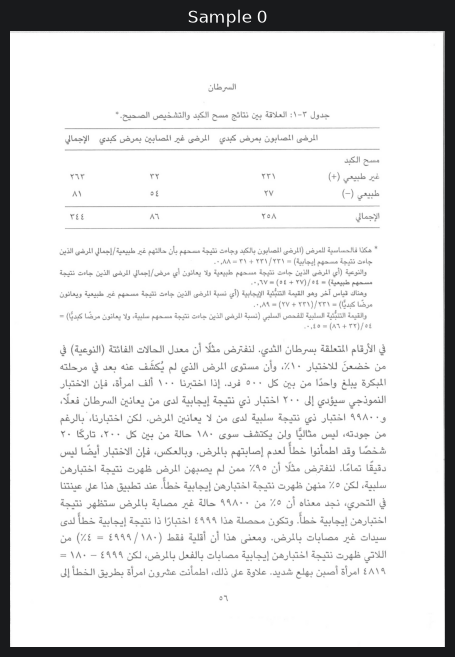

In [5]:
from PIL import Image
import io
import matplotlib.pyplot as plt

NUM = 1
for i in range(NUM):
    img_bytes = df.loc[i, "image"]["bytes"]
    img = Image.open(io.BytesIO(img_bytes))

    plt.figure(figsize=(6,8))
    plt.imshow(img)
    plt.title(f"Sample {i}")
    plt.axis("off")
    plt.show()

In [6]:
import io
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

def ask_choice(prompt, n):
    """Ask for a number between 1 and n, re-asking until it's valid."""
    while True:
        raw = input(prompt).strip()
        if raw.isdigit() and 1 <= int(raw) <= n:
            return int(raw) - 1
        print(f"Please enter a number between 1 and {n}.")


In [14]:
categories = sorted(df["category"].unique().tolist())

print("Choose a category:\n")
for i, cat in enumerate(categories, start=1):
    print(f"{i} - {cat}")

cat_idx = ask_choice(f"\nEnter a number (1-{len(categories)}): ", len(categories))
chosen_category = categories[cat_idx]

subset = df[df["category"] == chosen_category].reset_index(drop=True)
print(f"\nSelected category: {chosen_category}  ({len(subset)} image(s))")


Choose a category:

1 - Charts
2 - Headers
3 - graphics
4 - multi-columns
5 - tables
6 - text and images
7 - textonly
8 - titles

Selected category: tables  (24 image(s))


In [15]:
print(f"Images available in '{chosen_category}':\n")
for i in range(len(subset)):
    print(f"{i + 1} - image {i}  ({subset.loc[i, 'total_regions']} regions)")

img_idx = ask_choice(f"\nChoose an image (1-{len(subset)}): ", len(subset))
row = subset.loc[img_idx]

print(f"\nSelected: {chosen_category} / image {img_idx}")


Images available in 'tables':

1 - image 0  (6 regions)
2 - image 1  (6 regions)
3 - image 2  (10 regions)
4 - image 3  (8 regions)
5 - image 4  (8 regions)
6 - image 5  (7 regions)
7 - image 6  (3 regions)
8 - image 7  (3 regions)
9 - image 8  (11 regions)
10 - image 9  (6 regions)
11 - image 10  (5 regions)
12 - image 11  (5 regions)
13 - image 12  (6 regions)
14 - image 13  (5 regions)
15 - image 14  (6 regions)
16 - image 15  (10 regions)
17 - image 16  (7 regions)
18 - image 17  (9 regions)
19 - image 18  (6 regions)
20 - image 19  (6 regions)
21 - image 20  (5 regions)
22 - image 21  (7 regions)
23 - image 22  (5 regions)
24 - image 23  (6 regions)

Selected: tables / image 11


In [16]:
import ast

img_bytes = row["image"]["bytes"]
img = Image.open(io.BytesIO(img_bytes))

width, height = row["width"], row["height"]

# Safely evaluate the strings back into actual Python lists/tuples
region_types = ast.literal_eval(row["region_types"])
text_types = ast.literal_eval(row["text_types"])
norm_boxes = ast.literal_eval(row["normalized_bounding_boxes"])

def region_label(region_type, text_type):
    # Prefer the fine-grained text type (paragraph, heading, header, caption...);
    # fall back to the raw region tag (Table, Image, Graphic, Chart...) if absent.
    if text_type and str(text_type).lower() != "none":
        return str(text_type)
    return str(region_type).replace("Region", "") or str(region_type)

records = []
for j, (rtype, ttype, nbox) in enumerate(zip(region_types, text_types, norm_boxes)):
    x0, y0, x1, y1 = nbox[0], nbox[1], nbox[2], nbox[3]
    px_box = (round(x0 * width), round(y0 * height), round(x1 * width), round(y1 * height))
    records.append({
        "#": j,
        "region_type": rtype,
        "text_type": ttype,
        "label": region_label(rtype, ttype),
        "normalized_bbox": tuple(round(v, 4) for v in (x0, y0, x1, y1)),
        "pixel_bbox": px_box,
    })

print(f"image size: {width} x {height}    total_regions: {row['total_regions']}")
regions_df = pd.DataFrame(records)
regions_df

image size: 1653 x 2339    total_regions: 5


,#,region_type,text_type,label,normalized_bbox,pixel_bbox
0,0,TextRegion,header,header,"(0.3333, 0.0752, 0.6449, 0.0911)","(551, 176, 1066, 213)"
1,1,TextRegion,caption,caption,"(0.5064, 0.5203, 0.5239, 0.5366)","(837, 1217, 866, 1255)"
2,2,TextRegion,paragraph,paragraph,"(0.2365, 0.5601, 0.7471, 0.8666)","(391, 1310, 1235, 2027)"
3,3,TextRegion,page-number,page-number,"(0.4846, 0.9235, 0.5009, 0.9324)","(801, 2160, 828, 2181)"


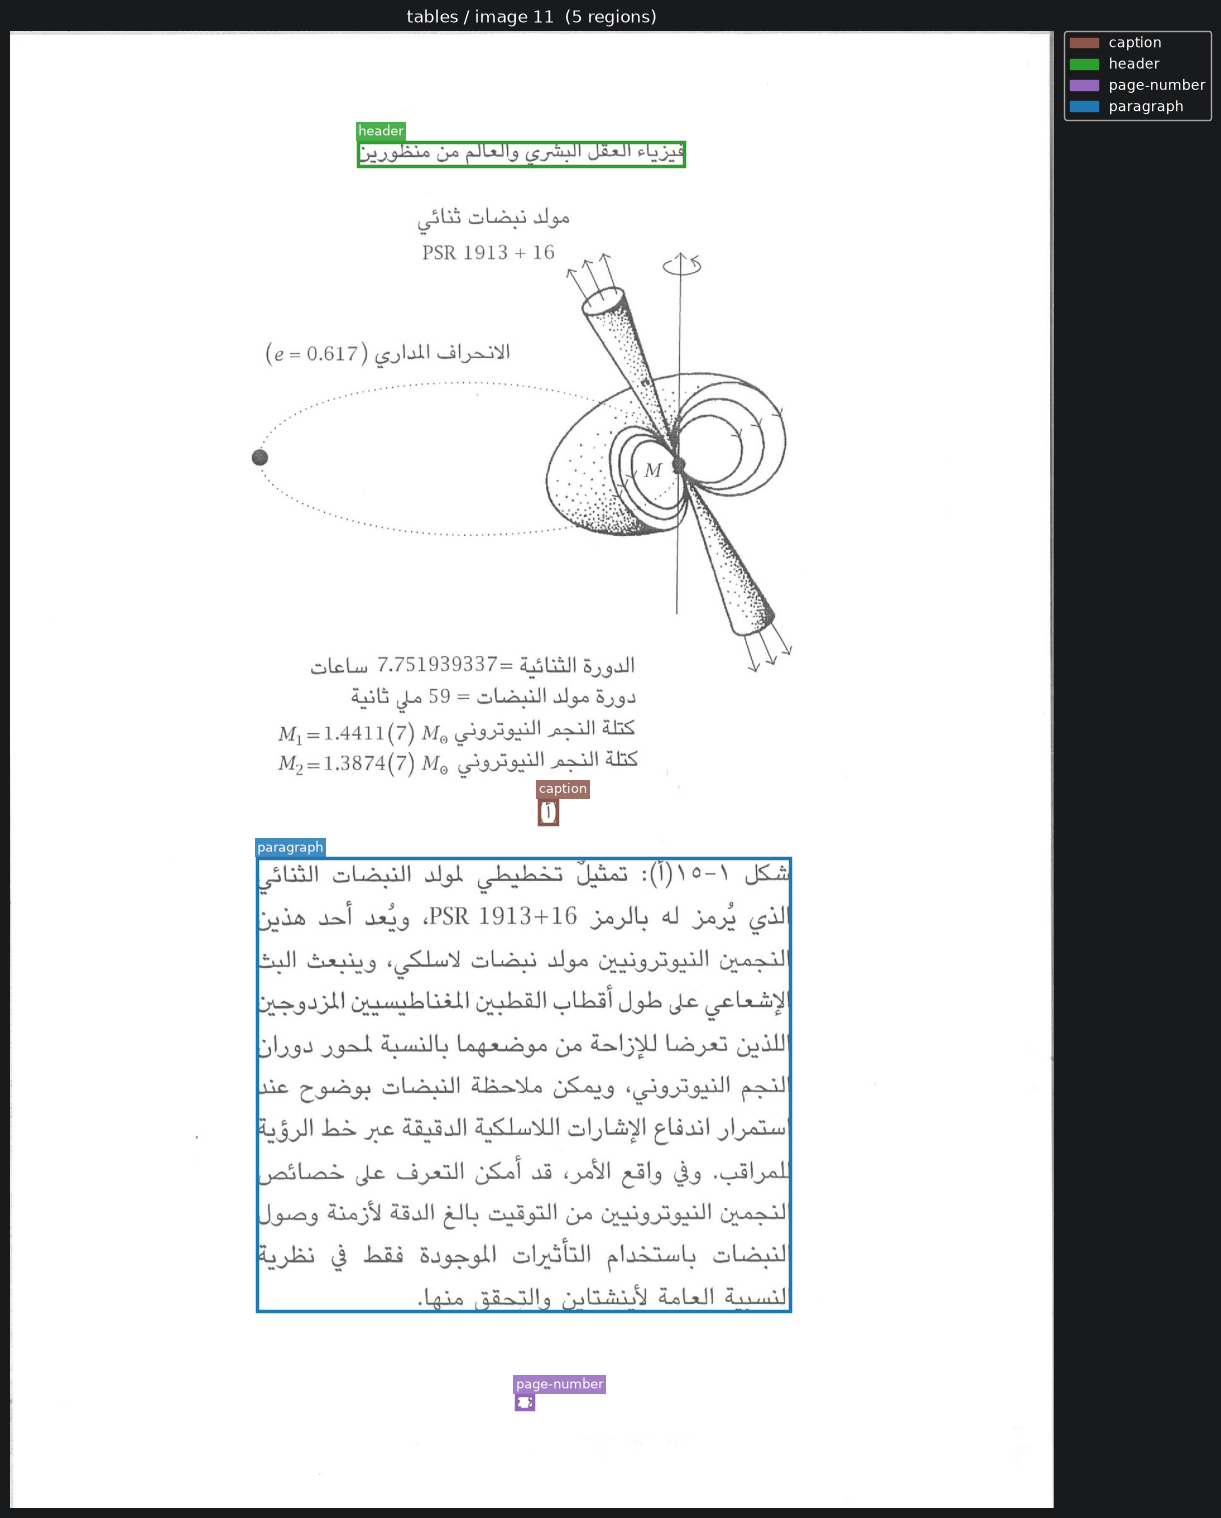

In [17]:
KNOWN_COLORS = {
    'paragraph': '#1f77b4',
    'heading': '#ff7f0e',
    'header': '#2ca02c',
    'footer': '#d62728',
    'page-number': '#9467bd',
    'caption': '#8c564b',
    'credit': '#e377c2',
    'floating': '#7f7f7f',
    'drop-capital': '#bcbd22',
    'footnote': '#ff9896',
    'Table': '#17becf',
    'Image': '#ffd700',
    'Graphic': '#00c853',
    'Chart': '#ff00ff',
    'LineDrawing': '#000080',
    'Separator': '#000000',
    'Noise': '#c0c0c0',
}
FALLBACK_CMAP = plt.colormaps.get_cmap('tab20')

unique_labels = sorted(regions_df["label"].unique().tolist())
color_map = {}
fallback_i = 0
for lab in unique_labels:
    if lab in KNOWN_COLORS:
        color_map[lab] = KNOWN_COLORS[lab]
    else:
        color_map[lab] = FALLBACK_CMAP(fallback_i % 20)
        fallback_i += 1

fig, ax = plt.subplots(figsize=(12, 16))
ax.imshow(img)

for rec in records:
    x0, y0, x1, y1 = rec["pixel_bbox"]
    color = color_map[rec["label"]]
    rect = mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               linewidth=2.5, edgecolor=color, facecolor='none')
    ax.add_patch(rect)
    ax.text(
        x0, max(y0 - 6, 0), rec["label"],
        fontsize=9, color='white', va='bottom',
        bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor='none'),
    )

legend_handles = [mpatches.Patch(color=color_map[l], label=l) for l in unique_labels]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)

ax.set_title(f"{chosen_category} / image {img_idx}  ({row['total_regions']} regions)")
ax.axis('off')
plt.tight_layout()
plt.show()
